# Red neuronal simple densa

Laboratorio 3, Deep Learning, ejercicio 5

En este notebook se trabaja con una red neuronal densa usando los tensores que ya salieron del pipeline. No se vuelven a cargar las imágenes originales ni se hace otro preprocesamiento, porque los datos ya vienen en escala de grises, con tamaño 64x64, normalizados entre 0 y 1 y con las etiquetas como números del 0 al 28.

La idea de este modelo es tener una base sencilla para comparar después contra las CNN. Como aquí la imagen se aplana, el modelo ya no recibe la relación espacial entre píxeles vecinos. 


In [1]:
import contextlib
import io
import json
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd().parent / ".matplotlib-cache"))
sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

import config as cfg
import modelado as m

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True

print("TensorFlow:", tf.__version__)
print("Entrada esperada:", cfg.FORMA_ENTRADA)
print("Clases:", cfg.NUM_CLASES)


Matplotlib is building the font cache; this may take a moment.


TensorFlow: 2.21.0
Entrada esperada: (64, 64, 1)
Clases: 29


## Carga de datos

Se usa la función cargar_tensores del módulo modelado para mantener el mismo protocolo que se va a usar con los otros modelos. En esta parte solo se trabaja con entrenamiento y validación. La partición de prueba no se toca, porque esa se tiene que reservar para la comparación final.


In [2]:
datos = m.cargar_tensores()

for nombre in ["x_train", "y_train", "x_val", "y_val", "x_test", "y_test"]:
    arreglo = datos[nombre]
    print(f"{nombre:7s} {arreglo.shape} {arreglo.dtype}")

print("Rango train:", float(datos["x_train"].min()), "a", float(datos["x_train"].max()))


[ok] entrada (64, 64, 1)
[cargado]  tensores -> train 12180, val 2610, test 2610
x_train (12180, 64, 64, 1) float32
y_train (12180,) int16
x_val   (2610, 64, 64, 1) float32
y_val   (2610,) int16
x_test  (2610, 64, 64, 1) float32
y_test  (2610,) int16
Rango train: 0.0 a 1.0


Lectura inicial: los tensores tienen el formato esperado para entrenar en Keras: N imágenes de 64x64 con un canal. Como las etiquetas son números enteros y no están en one-hot, la pérdida correcta es sparse categorical crossentropy.


In [3]:
def construir_red(capas, dropout):
    """Construye una red densa que aplana la imagen antes de clasificar."""
    modelo = tf.keras.Sequential(name="red_simple")
    modelo.add(tf.keras.layers.Input(shape=cfg.FORMA_ENTRADA))
    modelo.add(tf.keras.layers.Flatten(name="aplanado"))

    for i, unidades in enumerate(capas, 1):
        modelo.add(tf.keras.layers.Dense(unidades, activation="relu", name=f"densa_{i}"))
        if dropout > 0:
            modelo.add(tf.keras.layers.Dropout(dropout, name=f"dropout_{i}"))

    modelo.add(tf.keras.layers.Dense(cfg.NUM_CLASES, activation="softmax", name="salida"))
    return modelo


def compilar(modelo, learning_rate):
    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return modelo


def entrenar_variante(nombre, capas, dropout, learning_rate, batch_size, notas):
    print("Entrenando", nombre)
    print("capas=", capas, "dropout=", dropout, "lr=", learning_rate, "batch_size=", batch_size)

    modelo = construir_red(capas=capas, dropout=dropout)
    compilar(modelo, learning_rate=learning_rate)

    # Se captura la salida larga para que el notebook quede limpio y legible.
    salida = io.StringIO()
    with contextlib.redirect_stdout(salida):
        historial, tiempo = m.entrenar(modelo, datos, batch_size=batch_size)
        resultado = m.evaluar(modelo, datos)  # validacion por defecto
        registro = m.registrar(
            nombre,
            modelo,
            resultado,
            tiempo,
            historial=historial,
            batch_size=batch_size,
            notas=notas,
        )

    print("accuracy en validacion:", round(resultado["accuracy"], 4))
    print("epocas corridas:", len(historial.history["loss"]))
    print("tiempo de entrenamiento:", round(tiempo, 1), "s")
    print("parametros:", f"{modelo.count_params():,}")
    return modelo, historial, resultado, registro

def graficar_historial(historial, titulo):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(historial.history["loss"], label="train")
    axes[0].plot(historial.history["val_loss"], label="val")
    axes[0].set_title(f"{titulo}: loss")
    axes[0].set_xlabel("epoca")
    axes[0].legend()

    axes[1].plot(historial.history["accuracy"], label="train")
    axes[1].plot(historial.history["val_accuracy"], label="val")
    axes[1].set_title(f"{titulo}: accuracy")
    axes[1].set_xlabel("epoca")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


## Variante 1: punto de partida

Primero se probó una red con una sola capa oculta de 512 neuronas y dropout de 0.3. Se escogió como punto de partida porque no es demasiado pequeña, pero tampoco es una red exageradamente grande. Además, el dropout ayuda a que no memorice tan rápido.


Entrenando red_simple_v1
capas= [512] dropout= 0.3 lr= 0.001 batch_size= 64
accuracy en validacion: 0.1291
epocas corridas: 30
tiempo de entrenamiento: 107.0 s
parametros: 2,112,541


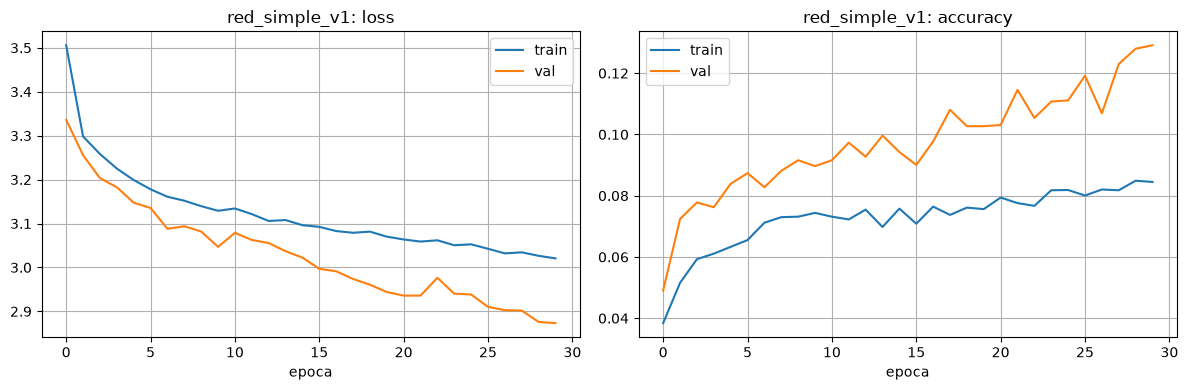

In [4]:
modelo_v1, hist_v1, res_v1, reg_v1 = entrenar_variante(
    nombre="red_simple_v1",
    capas=[512],
    dropout=0.3,
    learning_rate=0.001,
    batch_size=64,
    notas="1 capa oculta de 512, dropout 0.3, Adam lr=0.001",
)
graficar_historial(hist_v1, "red_simple_v1")


Discusión v1: esta primera corrida llegó a 0.1291 de accuracy en validación después de 30 épocas. El resultado es bajo, pero sirve como referencia inicial porque muestra qué pasa con una red densa relativamente sencilla. Como hay 29 clases, acertar al azar sería muy bajo, entonces la red sí aprende algo, pero todavía muy poco para el problema. El modelo mejora al inicio, pero se queda limitado rápido. Una posible razón es que al aplanar la imagen se pierde la relación entre píxeles cercanos. En este problema eso pesa bastante, porque muchas letras se distinguen por detalles pequeños de la mano, como la posición del pulgar o cuántos dedos están doblados. Por eso esta variante funciona como una base, pero no parece suficiente para capturar bien la estructura visual de las señas.


## Variante 2: más neuronas en una sola capa

Después se probó una capa más grande, con 1024 neuronas, y se subió el dropout a 0.5. La idea era ver si el problema era falta de capacidad. Si el modelo necesitaba más neuronas para combinar mejor los píxeles, esta variante debía mejorar.


Entrenando red_simple_v2
capas= [1024] dropout= 0.5 lr= 0.001 batch_size= 64
accuracy en validacion: 0.1989
epocas corridas: 19
tiempo de entrenamiento: 91.5 s
parametros: 4,225,053


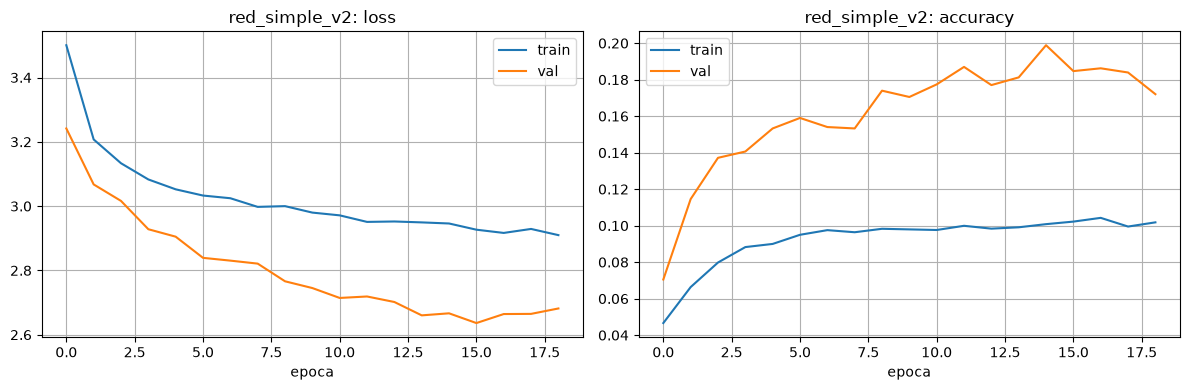

In [5]:
modelo_v2, hist_v2, res_v2, reg_v2 = entrenar_variante(
    nombre="red_simple_v2",
    capas=[1024],
    dropout=0.5,
    learning_rate=0.001,
    batch_size=64,
    notas="1 capa oculta de 1024, dropout 0.5, Adam lr=0.001",
)
graficar_historial(hist_v2, "red_simple_v2")


Discusión v2: esta variante subió a 0.1989 de accuracy en validación después de 19 épocas, así que mejoró frente a la primera prueba. Esto sugiere que aumentar el tamaño de la capa sí ayudó un poco, porque el modelo tuvo más capacidad para combinar los píxeles aplanados. Aun así, el resultado todavía quedó bastante lejos de la mejor variante. Una posible explicación es que el dropout de 0.5 fue demasiado fuerte. Durante el entrenamiento se apaga la mitad de las activaciones, y eso puede ayudar cuando hay mucho sobreajuste, pero también puede quitar demasiada información. Entonces, esta prueba muestra que hacer la red más grande puede ayudar, pero no basta por sí solo; también hay que cuidar el learning rate, el batch size y el nivel de regularización.


## Variante 3: dos capas ocultas

En la tercera prueba se usaron dos capas ocultas, una de 512 neuronas y otra de 256. Con esto se buscaba evaluar si una red un poco más profunda podía aprender mejores combinaciones de características antes de llegar a la salida.


Entrenando red_simple_v3
capas= [512, 256] dropout= 0.3 lr= 0.001 batch_size= 64
accuracy en validacion: 0.1322
epocas corridas: 17
tiempo de entrenamiento: 69.1 s
parametros: 2,236,445


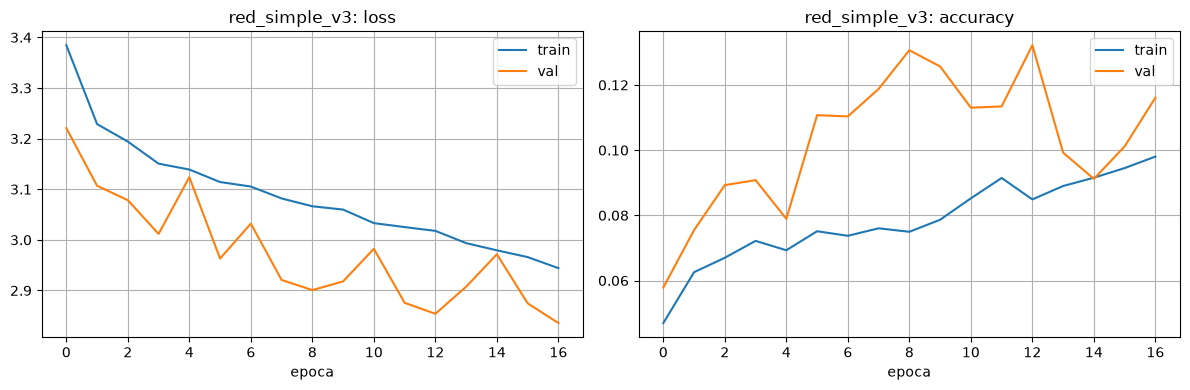

In [6]:
modelo_v3, hist_v3, res_v3, reg_v3 = entrenar_variante(
    nombre="red_simple_v3",
    capas=[512, 256],
    dropout=0.3,
    learning_rate=0.001,
    batch_size=64,
    notas="2 capas ocultas 512-256, dropout 0.3, Adam lr=0.001",
)
graficar_historial(hist_v3, "red_simple_v3")


Discusión v3: esta variante obtuvo 0.1322 de accuracy en validación después de 17 épocas. Aunque mejoró un poco respecto a v1, siguió siendo un resultado bajo. La idea de agregar profundidad era que la primera capa aprendiera combinaciones generales de píxeles y la segunda pudiera recombinarlas antes de clasificar. Sin embargo, el resultado sugiere que esa composición no ayudó demasiado en esta configuración. Puede ser que el learning rate de 0.001 haya sido muy alto para una red más profunda, o que el modelo se haya quedado aprendiendo patrones que no generalizan bien. También puede influir que, al trabajar con imágenes aplanadas, la red profunda sigue sin tener información explícita de vecindad espacial. Por eso, aunque tenga más capas, no necesariamente entiende mejor la forma de la mano.


## Variante 4: red más grande y aprendizaje más lento

Por último se probó una red más grande, con capas de 1024 y 512 neuronas, dropout de 0.4 y un learning rate más pequeño, de 0.0001. La idea fue darle más capacidad al modelo, pero hacer que aprendiera con pasos más pequeños para que el entrenamiento fuera más estable.


Entrenando red_simple_v4
capas= [1024, 512] dropout= 0.4 lr= 0.0001 batch_size= 128


accuracy en validacion: 0.5812
epocas corridas: 30
tiempo de entrenamiento: 113.6 s
parametros: 4,735,005


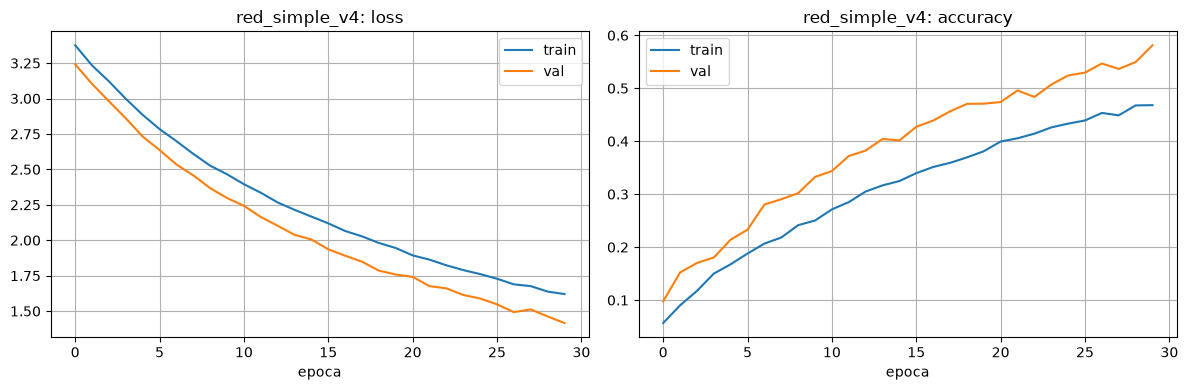

In [7]:
modelo_v4, hist_v4, res_v4, reg_v4 = entrenar_variante(
    nombre="red_simple_v4",
    capas=[1024, 512],
    dropout=0.4,
    learning_rate=0.0001,
    batch_size=128,
    notas="2 capas ocultas 1024-512, dropout 0.4, Adam lr=0.0001, batch size 128",
)
graficar_historial(hist_v4, "red_simple_v4")


Discusión v4: esta fue la mejor variante. Llegó a 0.5812 de accuracy en validación después de 30 épocas. La diferencia principal con las otras pruebas es que aquí se combinó una red más grande con un learning rate más bajo. Eso parece haber estabilizado el entrenamiento, porque el modelo pudo aprender con pasos más pequeños en lugar de cambiar demasiado rápido sus pesos. También se usó batch size de 128, lo cual puede hacer que las actualizaciones sean un poco más estables. El dropout de 0.4 funcionó mejor que el 0.5 de la segunda variante, porque regulariza sin apagar tanta información. Algo importante es que esta variante llegó hasta las 30 épocas, así que no se detuvo antes por EarlyStopping. Eso puede indicar que todavía tenía margen para seguir mejorando, pero se respetó el presupuesto común del laboratorio para que la comparación sea justa.


## Comparación interna de variantes

Para escoger la mejor variante solo se usa validación. No se usa x_test ni y_test, porque esas imágenes se deben guardar para la evaluación final entre todos los modelos.


In [8]:
registros = [reg_v1, reg_v2, reg_v3, reg_v4]
resumen = pd.DataFrame([
    {
        "modelo": r["nombre"],
        "accuracy_val": r["accuracy"],
        "epocas": r["epocas_corridas"],
        "tiempo_s": r["tiempo_entrenamiento_seg"],
        "batch_size": r["batch_size"],
        "notas": r["notas"],
    }
    for r in registros
]).sort_values("accuracy_val", ascending=False)

resumen


,modelo,accuracy_val,epocas,tiempo_s,batch_size,notas
3,red_simple_v4,0.581226,30,113.6,128,"2 capas ocultas 1024-512, dropout 0.4, Adam lr..."
1,red_simple_v2,0.198851,19,91.5,64,"1 capa oculta de 1024, dropout 0.5, Adam lr=0.001"
2,red_simple_v3,0.132184,17,69.1,64,"2 capas ocultas 512-256, dropout 0.3, Adam lr=..."
0,red_simple_v1,0.129119,30,107.0,64,"1 capa oculta de 512, dropout 0.3, Adam lr=0.001"


In [9]:
mejor = resumen.iloc[0]
print("Mejor variante por validación:")
print(mejor.to_string())


Mejor variante por validación:
modelo                                              red_simple_v4
accuracy_val                                             0.581226
epocas                                                         30
tiempo_s                                                    113.6
batch_size                                                    128
notas           2 capas ocultas 1024-512, dropout 0.4, Adam lr...


La mejor variante fue red_simple_v4, con 0.5812 de accuracy en validación. Después quedó red_simple_v2 con 0.1989, red_simple_v3 con 0.1322 y red_simple_v1 con 0.1291. Viendo estos resultados, la diferencia más importante no fue solo el número de neuronas, sino la combinación completa de hiperparámetros. La variante 1 fue la base, pero se quedó muy limitada. La variante 2 aumentó el número de neuronas y sí mejoró frente a v1, aunque el dropout de 0.5 pudo haber limitado su aprendizaje. La variante 3 agregó profundidad, pero no logró superar a v2, posiblemente porque la arquitectura no compensó la pérdida de información espacial causada por aplanar la imagen. En cambio, la variante 4 sí logró aprovechar mejor su capacidad porque usó un learning rate más conservador y una regularización más balanceada. Por eso se deja red_simple_v4 como la representante de la red simple para compararla después contra las CNN y el modelo clásico. Esta comparación sigue siendo interna y solo usa validación; no se usó la partición de prueba.


## Revisión de errores de la mejor variante

La matriz de confusión sirve para revisar si el modelo se equivoca más entre letras que se parecen visualmente, por ejemplo M, N, S, T, A y E, o también U, V, R y W. Esto es importante porque en ASL varias letras se diferencian por detalles pequeños en los dedos o en la posición del pulgar.


In [10]:
ruta_mejor = cfg.DIR_RESULTADOS / f"{mejor['modelo']}.json"
registro_mejor = json.loads(ruta_mejor.read_text(encoding="utf-8"))
matriz = np.array(registro_mejor["matriz_confusion"])

confusiones = []
for real in range(cfg.NUM_CLASES):
    for pred in range(cfg.NUM_CLASES):
        if real != pred and matriz[real, pred] > 0:
            confusiones.append({
                "real": cfg.CLASES[real],
                "predicho": cfg.CLASES[pred],
                "casos": int(matriz[real, pred]),
            })

pd.DataFrame(confusiones).sort_values("casos", ascending=False).head(15)


,real,predicho,casos
62,G,H,38
176,R,Q,26
278,Y,space,22
305,space,del,19
23,C,D,18
236,V,Z,16
88,J,H,16
194,S,T,15
218,U,R,15
192,S,Q,15


La tabla anterior muestra las confusiones más frecuentes de red_simple_v4. Esta parte es útil porque el accuracy general no cuenta toda la historia. En ASL hay grupos de letras que se parecen bastante entre sí, por ejemplo M, N, S, T, A y E, donde la diferencia puede depender de detalles pequeños en el pulgar o en los dedos doblados. También hay letras como U, V, R y W, que comparten dedos extendidos y pueden confundirse si el modelo no detecta bien la separación entre ellos. Si los errores más comunes aparecen dentro de esos grupos, entonces el comportamiento del modelo tiene sentido. La red densa aprende patrones globales de la imagen, pero no tiene filtros locales como una CNN para detectar bordes, curvas o posiciones específicas de los dedos. Por eso, aunque la mejor variante mejora bastante respecto a las demás, todavía puede confundirse en clases que necesitan entender detalles espaciales finos.


## Conclusión

La red neuronal simple funciona como una línea base útil, pero tiene una limitación clara: trata cada imagen como una lista de 4096 valores. Eso hace que pierda la relación natural entre píxeles cercanos, que en este problema es importante porque la forma de la mano depende de bordes, dedos y posiciones pequeñas.

La mejor configuración fue red_simple_v4, con dos capas ocultas de 1024 y 512 neuronas, dropout de 0.4, learning rate de 0.0001 y batch size de 128. Su accuracy de validación fue 0.5812. Este resultado muestra que una red densa sí puede aprender información útil de las imágenes preprocesadas, incluso sin usar convoluciones. Sin embargo, también deja claro que no basta con agregar más neuronas o más capas sin ajustar bien el entrenamiento. Por ejemplo, v2 mejoró frente a la base, pero no se acercó a v4, y v3 agregó profundidad sin lograr una mejora fuerte. red_simple_v4 queda como el mejor modelo de esta familia. Aun así, se espera que una CNN tenga mejor desempeño, porque sí aprovecha la estructura espacial de la imagen. En una seña, la ubicación relativa de los dedos y la forma de la mano importan mucho, y esa información se conserva mejor con capas convolucionales que con una imagen aplanada.
